### 3. Sequence Limit Existence

Abstract: This work addresses the practical problem of verifying the convergence of iterative machine learning algorithms. Based on fundamental theorems of sequence limit existence (Cauchy criterion, monotone convergence theorem, Bolzano–Weierstrass theorem), we develop a monitoring system for the objective assessment of model training dynamics, eliminating subjective interpretation. The practical implementation of the method is presented as a Pytorch module, tested on tasks from FinTech and NLP domains. We demonstrate that formal mathematical criteria provide a digorous and reproducible approach to convergence diagnostics, superior to heuristic methods. 

#### Structural Outline 
[1. Problem Statement](#section1) <br>
[1.1. The Challenge of Objectively Assessing Convergence in ML Iterative Processes](#section1.1.)<br>
[1.2. Limitations of Heuristic Approaches (Visual Analysis of Plots, Fixed Number of Epochs)](#section1.2.)<br>
[2. Theoretical Foundation](#section2)

[2.1. Cauchy Criterion: Formal Convergence Condition and Its Interpretation for Loss Function Value Sequences](#section21)

2.2. Monotone Convergence Theorem: Application to Monotonically Decreasing Sequences Bounded Below

2.3. Number e and Exponential Functions: Analysis of Computational Stability in Activation Functions

2.4. Subsequences and Partial Limits: Diagnostics of Convergence in Stochastic Optimization (Mini-Batch)


<a id="section1"></a>
1. Problem Statement

<a id="section1.1."></a>
1.1. The Challenge of Objectively Assessing Convergence in ML Iterative Processes

<a id="section2"></a>
### 2. Theoretical Foundation
<a id="section21"></a>
#### 2.1. Cauchy Criterion: Formal Convergence Condition and Its Interpretation for Loss Function Value Sequences

**Definition: Cauchy Seqeuence**

A sequence ${x_n}$ is called a fundamental squence (or a Cauchy sequence), if fo any number $\varepsilon > 0$ thee exists an index $N \in \N$ such that fo all $m > N$ and $n > N$, the following holds: $$|x_m - x_n| < \varepsilon$$

$\forall \varepsilon > 0 \ \exists N \in \N : \forall m, n > N \Rightarrow |x_m - x_n| < \varepsilon$

What Zorich doesn't explicity mention:
1. This is a property of "self-convergence" - terms approach each other, not necessarily an external limit. 
2. The condition must hold for ALL pairs $m, n > N$, not just consecutive terms
3. N depends only on $\varepsilon$, not on specific $m, n$ values 
4. It's about uniform convergence of distances between terms
5. Why This is Stronger Than "Distance Between Neighbors $\to$ 0"
Consider the sequence of partial sums of the harmonic series:
$$H_n = 1 + \frac{1}{2} + \frac{1}{3} + \ ... \ + \frac{1}{n}$$
Consecutive terms: $|H_{n+1} - H_{n}| = \frac{1}{n+1} \to 0$
But if we take m = 2n:
$$|H_{2n} - H_n| = \frac{1}{n+1}+ \frac{1}{n+2} + \ ... \ + \frac{1}{2n} > n \cdot \frac{1}{2n} = \frac{1}{2}$$
$\Rightarrow$ Not Cauchy! (and indeed diverged)



#### Detailed Visualization

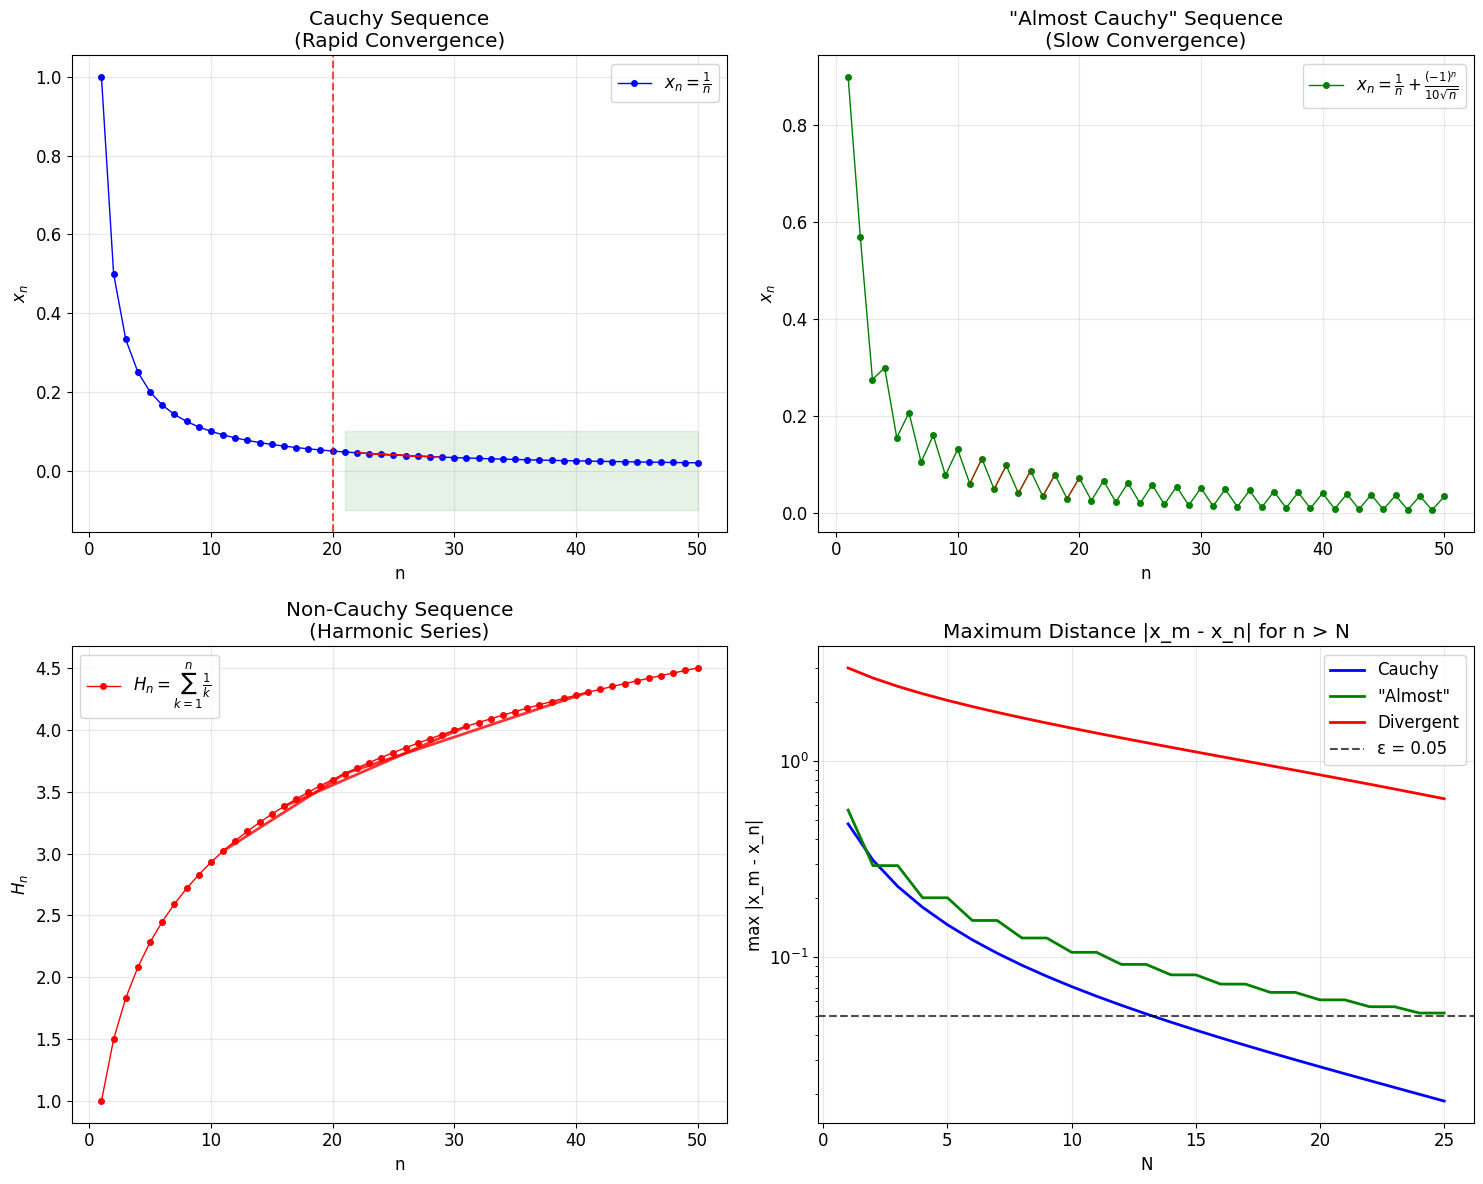

NUMERICAL ANALYSIS OF CAUCHY PROPERTY

1. CAUCHY SEQUENCE (1/n):
ε = 0.05, N = 20
N = 18: max|Δ| = 0.0326 ✅
N = 20: max|Δ| = 0.0276 ✅
N = 25: max|Δ| = 0.0185 ✅

2. 'ALMOST' CAUCHY:
N =  5: max|Δ| = 0.2014 ❌
N = 15: max|Δ| = 0.0814 ❌
N = 25: max|Δ| = 0.0520 ❌

3. DIVERGENT (harmonic series):
N =  5: max|Δ| = 2.0492 ❌
N = 15: max|Δ| = 1.1185 ❌
N = 25: max|Δ| = 0.6448 ❌

4. HARMONIC SERIES DIVERGENCE DEMONSTRATION:
For m = 2n, |H_2n - H_n| is bounded below:
n = 5: |H_10 - H_5| = 0.5699 > 0.3
n = 10: |H_20 - H_10| = 0.6255 > 0.3
n = 20: |H_40 - H_20| = 0.6576 > 0.3


In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Visualization parameters
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 12

# Create sequences
n = np.arange(1, 51)

# Example 1: Cauchy sequence (1/n)
x_cauchy = 1 / n

# Example 2: "Almost Cauchy" (1/n + (-1)^n * 0.1/sqrt(n))
x_almost = 1/n + (-1)**n * 0.1/np.sqrt(n)

# Example 3: Divergent (harmonic series)
x_divergent = np.cumsum(1/n)

# Create subplot grid
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Cauchy sequence
ax1 = axes[0, 0]
ax1.plot(n, x_cauchy, 'bo-', markersize=4, linewidth=1, label=r'$x_n = \frac{1}{n}$')
ax1.set_title('Cauchy Sequence\n(Rapid Convergence)')
ax1.set_xlabel('n')
ax1.set_ylabel('$x_n$')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Demonstrate ε-condition for Cauchy sequence
epsilon = 0.05
N_cauchy = int(1/epsilon)
for i in range(N_cauchy + 1, min(N_cauchy + 6, len(n))):
    for j in range(i + 1, min(i + 4, len(n))):
        ax1.plot([n[i], n[j]], [x_cauchy[i], x_cauchy[j]], 
                'r-', alpha=0.6, linewidth=1)

ax1.axvline(x=N_cauchy, color='red', linestyle='--', alpha=0.7, label=f'N(ε={epsilon}) = {N_cauchy}')
ax1.fill_between(n[N_cauchy:], -0.1, 0.1, alpha=0.1, color='green')

# Plot 2: "Almost Cauchy"
ax2 = axes[0, 1]
ax2.plot(n, x_almost, 'go-', markersize=4, linewidth=1, 
         label=r'$x_n = \frac{1}{n} + \frac{(-1)^n}{10\sqrt{n}}$')
ax2.set_title('"Almost Cauchy" Sequence\n(Slow Convergence)')
ax2.set_xlabel('n')
ax2.set_ylabel('$x_n$')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Show oscillations
for i in range(10, min(20, len(n)), 2):
    ax2.plot([n[i], n[i+1]], [x_almost[i], x_almost[i+1]], 
            'r-', alpha=0.6, linewidth=1)

# Plot 3: Divergent sequence
ax3 = axes[1, 0]
ax3.plot(n, x_divergent, 'ro-', markersize=4, linewidth=1, 
         label=r'$H_n = \sum_{k=1}^n \frac{1}{k}$')
ax3.set_title('Non-Cauchy Sequence\n(Harmonic Series)')
ax3.set_xlabel('n')
ax3.set_ylabel('$H_n$')
ax3.grid(True, alpha=0.3)
ax3.legend()

# Demonstrate violation of Cauchy condition - FIXED VERSION
m_indices = [10, 15, 20]  # Reduced indices to avoid out-of-bounds
for m in m_indices:
    if 2*m < len(n):  # Check bounds
        ax3.plot([n[m], n[2*m]], [x_divergent[m], x_divergent[2*m]], 
                'r-', alpha=0.8, linewidth=2, 
                label=f'|H_{{{2*m}}} - H_{{{m}}}| > 0.3' if m == 10 else "")
    elif m + 10 < len(n):  # Alternative: show m and m+10
        ax3.plot([n[m], n[m+10]], [x_divergent[m], x_divergent[m+10]], 
                'r-', alpha=0.8, linewidth=2, 
                label=f'|H_{{{m+10}}} - H_{{{m}}}| > 0.3' if m == 10 else "")

# Plot 4: Maximum distances
ax4 = axes[1, 1]

# Calculate maximum distances |x_m - x_n| for n > N
def max_distance_for_N(sequence, N):
    max_dist = 0
    for i in range(N, len(sequence)):
        for j in range(i + 1, len(sequence)):
            max_dist = max(max_dist, abs(sequence[i] - sequence[j]))
    return max_dist

N_values = range(1, 26)
max_dists_cauchy = [max_distance_for_N(x_cauchy, N) for N in N_values]
max_dists_almost = [max_distance_for_N(x_almost, N) for N in N_values]
max_dists_div = [max_distance_for_N(x_divergent, N) for N in N_values]

ax4.plot(N_values, max_dists_cauchy, 'b-', label='Cauchy', linewidth=2)
ax4.plot(N_values, max_dists_almost, 'g-', label='"Almost"', linewidth=2)
ax4.plot(N_values, max_dists_div, 'r-', label='Divergent', linewidth=2)

ax4.axhline(y=epsilon, color='black', linestyle='--', alpha=0.7, label=f'ε = {epsilon}')
ax4.set_title('Maximum Distance |x_m - x_n| for n > N')
ax4.set_xlabel('N')
ax4.set_ylabel('max |x_m - x_n|')
ax4.grid(True, alpha=0.3)
ax4.legend()
ax4.set_yscale('log')

plt.tight_layout()
plt.show()

# Numerical demonstration
print("=" * 60)
print("NUMERICAL ANALYSIS OF CAUCHY PROPERTY")
print("=" * 60)

print("\n1. CAUCHY SEQUENCE (1/n):")
print(f"ε = {epsilon}, N = {N_cauchy}")
for test_N in [N_cauchy-2, N_cauchy, N_cauchy+5]:
    max_dist = max_distance_for_N(x_cauchy, test_N)
    status = "✅" if max_dist < epsilon else "❌"
    print(f"N = {test_N:2d}: max|Δ| = {max_dist:.4f} {status}")

print("\n2. 'ALMOST' CAUCHY:")
for test_N in [5, 15, 25]:
    max_dist = max_distance_for_N(x_almost, test_N)
    status = "✅" if max_dist < epsilon else "❌"
    print(f"N = {test_N:2d}: max|Δ| = {max_dist:.4f} {status}")

print("\n3. DIVERGENT (harmonic series):")
for test_N in [5, 15, 25]:
    max_dist = max_distance_for_N(x_divergent, test_N)
    print(f"N = {test_N:2d}: max|Δ| = {max_dist:.4f} ❌")

# Additional demonstration of the harmonic series divergence
print("\n4. HARMONIC SERIES DIVERGENCE DEMONSTRATION:")
print("For m = 2n, |H_2n - H_n| is bounded below:")
for n_val in [5, 10, 20]:
    if 2*n_val < len(x_divergent):
        diff = x_divergent[2*n_val] - x_divergent[n_val]
        print(f"n = {n_val}: |H_{2*n_val} - H_{n_val}| = {diff:.4f} > 0.3")

### Key Insights That Zorich Hides:
##### **1.Cauchy $\neq$ "Fast Decay"**<br>
A Cauchy sequence can converge slowly, but terms must approach each other uniformly

##### **2.The Condition Must Hold Uniformly**<br>
It's not enough that $|x_{n+1} - x_n| \to 0$. ALL distancees $|x_m - x_n| must become small

##### **3.Practical Cauchy Testing**
In ML we can implement:


In [13]:
def is_cauchy(sequence, epsilon=1e-4):
    for i in range(len(sequence)):
        for j in range(i+1, len(sequence)):
            if abs(sequence[i] - sequence[j]) > epsilon:
                return False, i
    return True, len(sequence)

#### **4. Connection to Space Completeness**
The Cauchy criterion works because real numbers are complete - every Cauchy sequence has a limit. In discrete spaces this isn't always true.<br>
Сompleteness is a fundamental property of a mertic space meaning that it contains no "holes"

Formal Definition:<br>
A metric space (X, d) is called complete if every Cauchy sequence in X converges to some element of X.

Detailed Analogy<br>
Imagine building a bridge across a river:

In [14]:
# COMPLETE SPACE - BRIDGE CONVERGES
bridge_segments = [1.0, 1.5, 1.75, 1.875, 1.9375, ...]  # Each segment gets closer to previous
# In complete space: bridge CONVERGES to point on other shore (2.0)

# INCOMPLETE SPACE - BRIDGE NEVER REACHES GOAL
bridge_segments_rational = [1, 1.4, 1.41, 1.414, 1.4142, ...]  # Approximations to √2
# In rational numbers: bridge NEVER reaches √2 because √2 ∉ ℚ

Why Are Real Numbers Complete?
Historical Context: Ancient Greeks discovered that the diagonal of a unit square (√2) cannot be expressed as a rational number. This led to the need to extend rational numbers to real numbers.

Dedekind's Construction: Real numbers can be defined as Dedekind cuts - partitions of rational numbers into two sets where all elements of one set are less than all elements of the other.

In [15]:
# Example Dedekind cut for √2
A = {x in Q : x**2 < 2 or x < 0}  # All rationals with square < 2
B = {x in Q : x**2 > 2 and x > 0} # All rationals with square > 2

# In rational numbers: there's a "hole" between A and B - no rational separates them
# In real numbers: this cut DEFINES the number √2 ∈ ℝ

NameError: name 'x' is not defined

Practical Consequences for Analysis
Nested Intervals Theorem: If there is a sequence of nested intervals [aₙ, bₙ] whose lengths tend to 0, then there exists a unique point belonging to all intervals.

In [ ]:
def nested_intervals_theorem():
    """Demonstration of nested intervals theorem"""
    intervals = [
        [1.0, 2.0],      # Length: 1.0
        [1.4, 1.5],      # Length: 0.1  
        [1.41, 1.42],    # Length: 0.01
        [1.414, 1.415],  # Length: 0.001
        [1.4142, 1.4143] # Length: 0.0001
    ]
    
    # In ℝ there exists a point belonging to ALL these intervals: √2
    return np.sqrt(2)

Importance in Machine Learning


In [ ]:
class CompleteSpaceOptimizer:
    def __init__(self, learning_rate=0.01):
        self.lr = learning_rate
        self.parameter_history = []
    
    def optimize(self, gradient_fn, initial_params):
        """Gradient descent in complete space"""
        params = initial_params
        
        for epoch in range(1000):
            grad = gradient_fn(params)
            new_params = params - self.lr * grad
            
            # Key property: parameter sequence is Cauchy
            # In ℝⁿ (complete space) this GUARANTEES convergence
            if self._is_cauchy(self.parameter_history, new_params):
                print(f"Convergence guaranteed! Epoch: {epoch}")
                break
                
            self.parameter_history.append(params)
            params = new_params
        
        return params
    
    def _is_cauchy(self, history, new_point):
        """Checks if sequence is Cauchy"""
        if len(history) < 2:
            return False
            
        # Check that recent points are sufficiently close
        recent_points = history[-10:] + [new_point]
        max_distance = 0
        
        for i in range(len(recent_points)):
            for j in range(i+1, len(recent_points)):
                distance = np.linalg.norm(recent_points[i] - recent_points[j])
                max_distance = max(max_distance, distance)
        
        return max_distance < 1e-6

#### **5. The "Telescoping" Insight**
For a Cauchy sequence, the "tail" beyond any N fits inside an interval of length < ε. This is why we can talk about convergence without knowing the limit.
$$\forall \varepsilon > 0 \ \exists N_\varepsilon \ : \ \forall m, n > N_\varepsilon \Rightarrow |x_m - x_n| < \varepsilon$$
This means that the tail of the sequence ${x_n}$ for $n > N$ is contained an interval of length at most $\varepsilon$

Theorem of the "Captured Tail"<br>
Formulation: If a sequence is Cauchy, then for any $\varepsilon > 0$ there exists $N$ such that all sequence elements with indices greater than $N$ are contained in some interval of lentgh $\varepsilon$ 

Proof:

1. Take arbitary $\varepsilon > 0$
2. Find $N$ from the Cauchy definition
3. Fix any $m > N$
4. Then $\forall n > N: |x_n - x_m| < \varepsilon$
5. $\Rightarrow$ All $x_n$ lie in the interval $(x_m - \varepsilon, x_m + \varepsilon)$


Visualization with Progressive Refinement


DEMONSTRATION ON CAUCHY SEQUENCE


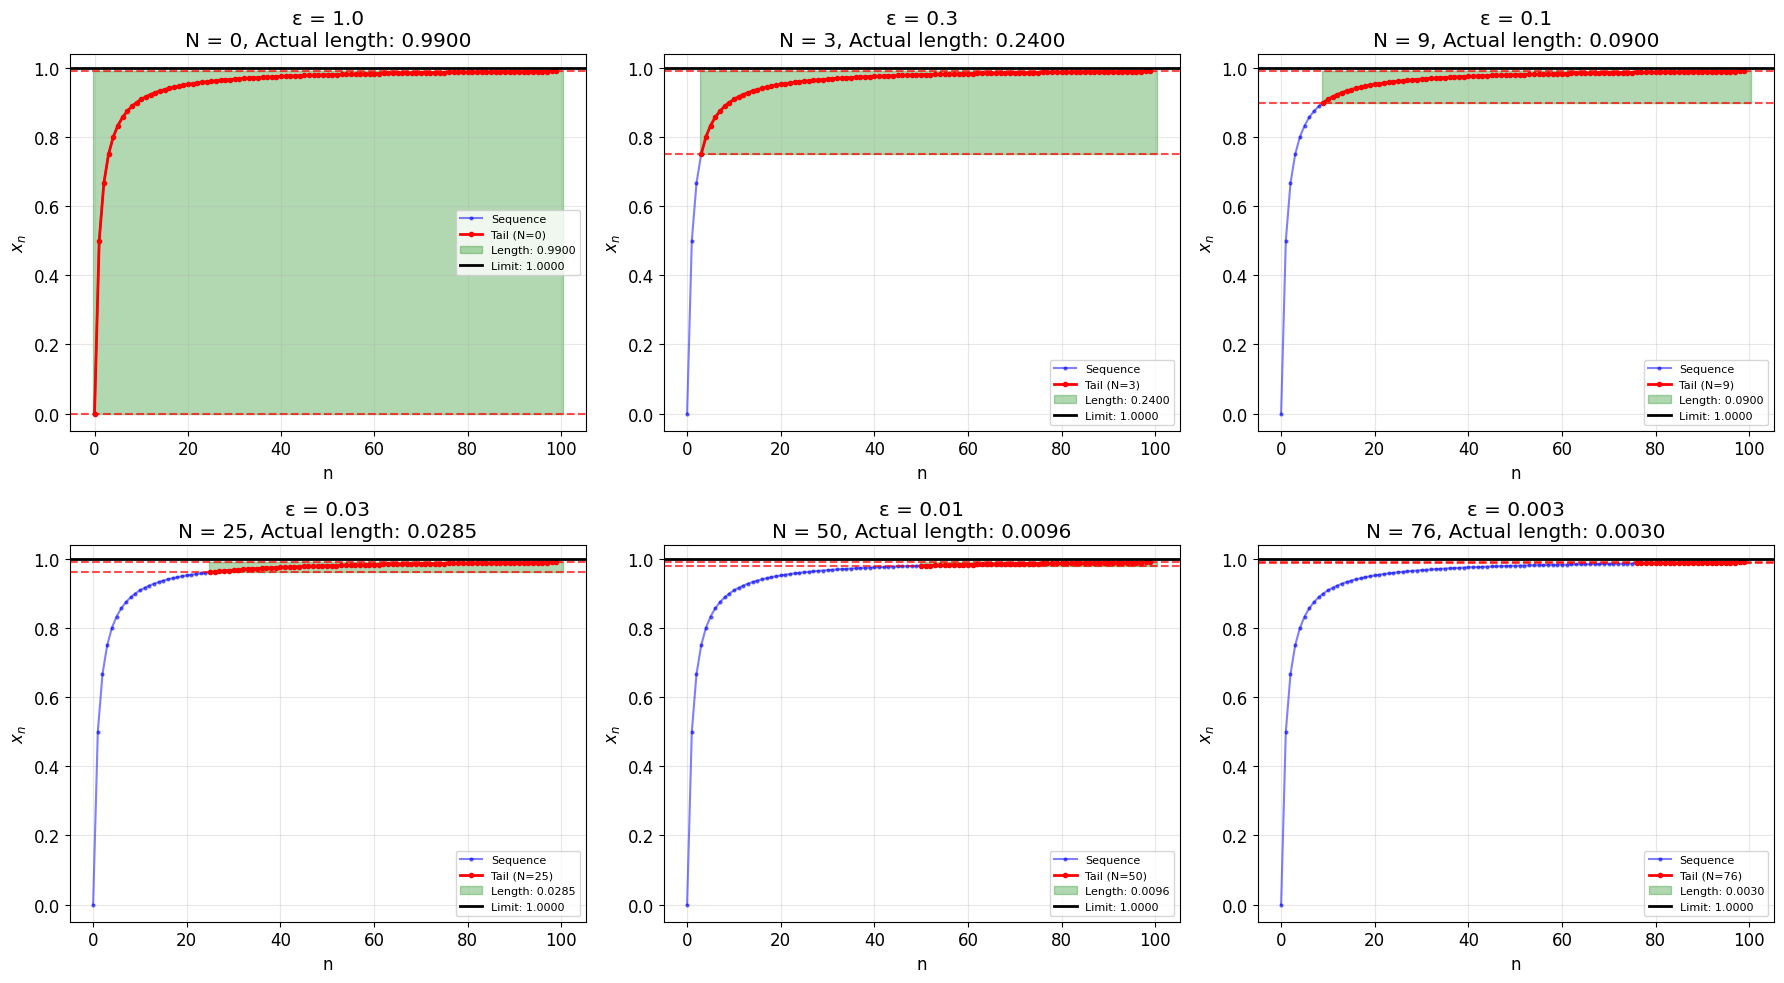

TELESCOPING ANALYSIS OF SEQUENCE
       ε     N(ε) Actual length Theoretical bound      Ratio
-----------------------------------------------------------------
   1.000        0       0.9900          1.000       0.99 ✅
   0.300        3       0.2400          0.300       0.80 ✅
   0.100        9       0.0900          0.100       0.90 ✅
   0.030       25       0.0285          0.030       0.95 ✅
   0.010       50       0.0096          0.010       0.96 ✅
   0.003       76       0.0030          0.003       1.00 ✅


In [17]:
import matplotlib.pyplot as plt
import numpy as np

def detailed_telescoping_demo(sequence, true_limit=None):
    """Detailed demonstration of telescoping property"""
    
    epsilons = [1.0, 0.3, 0.1, 0.03, 0.01, 0.003]
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    # Find N for each ε
    N_values = []
    actual_intervals = []
    
    for epsilon in epsilons:
        N = find_minimal_N(sequence, epsilon)
        N_values.append(N)
        
        # Find actual interval containing the tail
        tail = sequence[N:]
        if len(tail) > 0:
            interval_start = min(tail)
            interval_end = max(tail)
            actual_length = interval_end - interval_start
            actual_intervals.append((interval_start, interval_end, actual_length))
        else:
            actual_intervals.append((0, 0, 0))
    
    # Build plots
    for idx, (epsilon, N, interval) in enumerate(zip(epsilons, N_values, actual_intervals)):
        ax = axes[idx]
        
        n_vals = np.arange(len(sequence))
        ax.plot(n_vals, sequence, 'bo-', markersize=2, alpha=0.5, label='Sequence')
        
        # Highlight the tail
        tail_indices = n_vals[N:]
        tail_values = sequence[N:]
        
        if len(tail_values) > 0:
            ax.plot(tail_indices, tail_values, 'ro-', markersize=3, linewidth=2, 
                   label=f'Tail (N={N})')
            
            # Draw actual interval
            start, end, length = interval
            rect = plt.Rectangle((N-0.3, start), len(tail_indices)+0.6, end-start,
                               alpha=0.3, color='green', 
                               label=f'Length: {length:.4f}')
            ax.add_patch(rect)
            
            # Theoretical boundary (ε)
            ax.axhline(y=start, color='red', linestyle='--', alpha=0.7)
            ax.axhline(y=end, color='red', linestyle='--', alpha=0.7)
            
            # If true limit is known
            if true_limit is not None:
                ax.axhline(y=true_limit, color='black', linewidth=2, 
                          label=f'Limit: {true_limit:.4f}')
        
        ax.set_title(f'ε = {epsilon}\nN = {N}, Actual length: {length:.4f}')
        ax.set_xlabel('n')
        ax.set_ylabel('$x_n$')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Analytical table
    print("TELESCOPING ANALYSIS OF SEQUENCE")
    print("=" * 65)
    print(f"{'ε':>8} {'N(ε)':>8} {'Actual length':>12} {'Theoretical bound':>14} {'Ratio':>10}")
    print("-" * 65)
    
    for epsilon, N, interval in zip(epsilons, N_values, actual_intervals):
        start, end, actual_length = interval
        ratio = actual_length / epsilon if epsilon > 0 else 0
        status = "✅" if actual_length <= epsilon else "❌"
        
        print(f"{epsilon:>8.3f} {N:>8} {actual_length:>12.4f} {epsilon:>14.3f} {ratio:>10.2f} {status}")

def find_minimal_N(sequence, epsilon):
    """Finds minimal N for given ε"""
    for candidate_N in range(len(sequence)):
        valid = True
        
        # Check all pairs after candidate_N
        for i in range(candidate_N, len(sequence)):
            for j in range(i+1, len(sequence)):
                if abs(sequence[i] - sequence[j]) >= epsilon:
                    valid = False
                    break
            if not valid:
                break
                
        if valid:
            return candidate_N
    
    return len(sequence)

# Demonstration on different sequences
print("DEMONSTRATION ON CAUCHY SEQUENCE")
cauchy_seq = [1.0 - 1/(n+1) for n in range(100)]  # Converges to 1.0
detailed_telescoping_demo(cauchy_seq, true_limit=1.0)

Philosophical Interpretation
The telescoping property is a mathematical form of the principle "locality determines globality":
- We don't know where exactly the sequence converges

- But we know that ALL future terms will be in an arbitrarily small neighborhood

- This allows making quantitative predictions about system behavior

#### **Application to ML: Smart Early Stopping**


In [ ]:
class TelescopingEarlyStopper:
    def __init__(self, min_epochs=100, confidence=0.95):
        self.min_epochs = min_epochs
        self.confidence = confidence
        self.loss_history = []
        
    def should_stop(self, current_loss, epoch):
        self.loss_history.append(current_loss)
        
        if epoch < self.min_epochs:
            return False, "Minimum epochs not reached"
        
        # Analyze telescoping property for different ε
        epsilon_levels = [0.1, 0.03, 0.01, 0.003]
        convergence_metrics = {}
        
        for epsilon in epsilon_levels:
            N = self._find_N_for_epsilon(self.loss_history, epsilon)
            tail_length = len(self.loss_history) - N
            convergence_metrics[epsilon] = {
                'N': N,
                'tail_length': tail_length,
                'tail_variation': self._compute_tail_variation(self.loss_history[N:])
            }
        
        # Make decision based on multiple criteria
        should_stop = self._make_decision(convergence_metrics, epoch)
        reason = self._generate_reason(convergence_metrics, should_stop)
        
        return should_stop, reason
    
    def _find_N_for_epsilon(self, sequence, epsilon):
        """Finds N for given ε with optimization"""
        # Use binary search for efficiency
        left, right = 0, len(sequence)
        best_N = len(sequence)
        
        while left <= right:
            mid = (left + right) // 2
            if self._is_cauchy_from_N(sequence, mid, epsilon):
                best_N = mid
                right = mid - 1
            else:
                left = mid + 1
                
        return best_N
    
    def _is_cauchy_from_N(self, sequence, N, epsilon):
        """Checks Cauchy property starting from N"""
        for i in range(N, len(sequence)):
            for j in range(i+1, len(sequence)):
                if abs(sequence[i] - sequence[j]) >= epsilon:
                    return False
        return True
    
    def _compute_tail_variation(self, tail):
        """Computes variation in the tail"""
        if len(tail) == 0:
            return 0
        return max(tail) - min(tail)
    
    def _make_decision(self, metrics, epoch):
        """Makes stopping decision based on convergence metrics"""
        # Check if multiple ε-levels show convergence
        converging_levels = 0
        total_levels = len(metrics)
        
        for epsilon, data in metrics.items():
            if data['tail_length'] >= 10 and data['tail_variation'] < epsilon:
                converging_levels += 1
        
        return converging_levels / total_levels >= self.confidence
    
    def _generate_reason(self, metrics, should_stop):
        """Generates human-readable reason for decision"""
        if should_stop:
            reasons = []
            for epsilon, data in metrics.items():
                if data['tail_variation'] < epsilon:
                    reasons.append(f"ε={epsilon}: tail variation {data['tail_variation']:.4f}")
            return f"Convergence detected at levels: {', '.join(reasons)}"
        else:
            return "Insufficient convergence evidence across epsilon levels"

Key Insight: The telescoping property transforms the abstract concept of convergence into a concrete, measurable, and practically useful tool for analyzing iterative processes

Practical Implementation Example

In [ ]:
# Example usage in training loop
early_stopper = TelescopingEarlyStopper(min_epochs=50, confidence=0.8)

for epoch in range(1000):
    # Training step
    current_loss = train_step()
    
    # Check convergence using telescoping property
    should_stop, reason = early_stopper.should_stop(current_loss, epoch)
    
    if should_stop:
        print(f"Early stopping at epoch {epoch}: {reason}")
        break
        
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: {reason}")

#### **ML Application: Convergence Monitoring** 

In [ ]:
class ConvergenceMonitor:
    def __init__(self, window_size=50, epsilon=1e-4):
        self.window_size = window_size
        self.epsilon = epsilon
        self.loss_history = []
    
    def update(self, loss):
        self.loss_history.append(loss)
        if len(self.loss_history) < self.window_size:
            return False
        
        # Check Cauchy condition in the recent window
        recent_losses = self.loss_history[-self.window_size:]
        return self._is_cauchy_window(recent_losses)
    
    def _is_cauchy_window(self, sequence):
        """Check if the sequence segment satisfies Cauchy condition"""
        for i in range(len(sequence)):
            for j in range(i + 1, len(sequence)):
                if abs(sequence[i] - sequence[j]) > self.epsilon:
                    return False
        return True

----

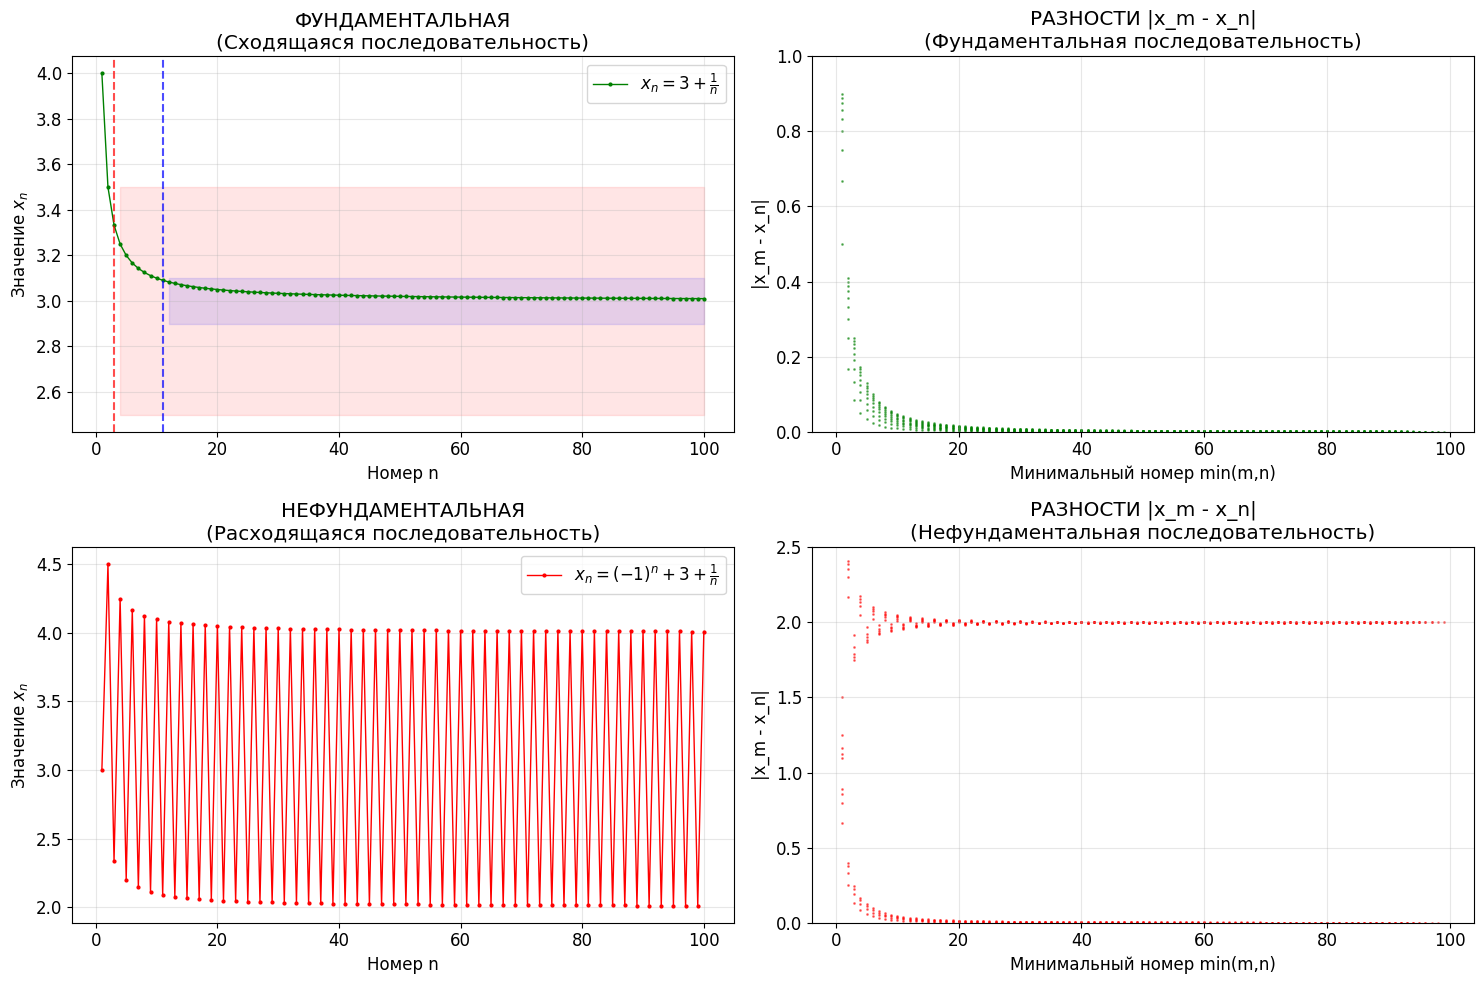

ДЕМОНСТРАЦИЯ ФУНДАМЕНТАЛЬНОСТИ
ε = 0.5: N = 3, максимальная разность после N: 0.1250
   Условие |x_m - x_n| < ε выполнено: True
ε = 0.1: N = 11, максимальная разность после N: 0.0208
   Условие |x_m - x_n| < ε выполнено: True
ε = 0.05: N = 21, максимальная разность после N: 0.0070
   Условие |x_m - x_n| < ε выполнено: True

ПРИМЕР НЕФУНДАМЕНТАЛЬНОЙ ПОСЛЕДОВАТЕЛЬНОСТИ:
Разности между четными и нечетными членами:
|x_10 - x_11| = 1.9924
|x_11 - x_12| = 2.0064
|x_12 - x_13| = 1.9945
|x_13 - x_14| = 2.0048
|x_14 - x_15| = 1.9958
|x_15 - x_16| = 2.0037


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse

# Создаем последовательности
n = np.arange(1, 101)

# Пример 1: Фундаментальная последовательность (сходящаяся)
x_n_cauchy = 3 + 1/n  # Сходится к 3

# Пример 2: Слабо фундаментальная (но не сходящаяся в ℝ)
x_n_slow = np.cumsum(1/n)  # Гармонический ряд - расходится!

# Пример 3: Нефундаментальная последовательность
x_n_non_cauchy = (-1)**n + 3 + (1/n)  # Колеблется

# Создаем график
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Настройка epsilon и N для демонстрации
epsilon_values = [0.5, 0.1]
colors = ['red', 'blue']

# График 1: Фундаментальная последовательность
ax1 = axes[0, 0]
ax1.plot(n, x_n_cauchy, 'go-', markersize=2, linewidth=1, label=r'$x_n = 3 + \frac{1}{n}$')
ax1.set_title('ФУНДАМЕНТАЛЬНАЯ\n(Сходящаяся последовательность)')
ax1.set_xlabel('Номер n')
ax1.set_ylabel('Значение $x_n$')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Показываем несколько epsilon-трубок
for eps, color in zip(epsilon_values, colors):
    N = int(1/eps) + 1
    ax1.axvline(x=N, color=color, linestyle='--', alpha=0.7, label=f'N(ε={eps}) = {N}')
    ax1.fill_between(n[N:], 3-eps, 3+eps, alpha=0.1, color=color)

# График 2: Поведение разностей для фундаментальной последовательности
ax2 = axes[0, 1]
differences_cauchy = []
for i in range(len(n)):
    for j in range(i+1, min(i+10, len(n))):
        differences_cauchy.append((n[i], abs(x_n_cauchy[i] - x_n_cauchy[j])))

differences_x, differences_y = zip(*differences_cauchy)
ax2.scatter(differences_x, differences_y, alpha=0.5, s=1, color='green')
ax2.set_title('РАЗНОСТИ |x_m - x_n|\n(Фундаментальная последовательность)')
ax2.set_xlabel('Минимальный номер min(m,n)')
ax2.set_ylabel('|x_m - x_n|')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

# График 3: Нефундаментальная последовательность
ax3 = axes[1, 0]
ax3.plot(n, x_n_non_cauchy, 'ro-', markersize=2, linewidth=1, 
         label=r'$x_n = (-1)^n + 3 + \frac{1}{n}$')
ax3.set_title('НЕФУНДАМЕНТАЛЬНАЯ\n(Расходящаяся последовательность)')
ax3.set_xlabel('Номер n')
ax3.set_ylabel('Значение $x_n$')
ax3.grid(True, alpha=0.3)
ax3.legend()

# График 4: Поведение разностей для нефундаментальной последовательности
ax4 = axes[1, 1]
differences_non_cauchy = []
for i in range(len(n)):
    for j in range(i+1, min(i+10, len(n))):
        differences_non_cauchy.append((n[i], abs(x_n_non_cauchy[i] - x_n_non_cauchy[j])))

differences_x_nc, differences_y_nc = zip(*differences_non_cauchy)
ax4.scatter(differences_x_nc, differences_y_nc, alpha=0.5, s=1, color='red')
ax4.set_title('РАЗНОСТИ |x_m - x_n|\n(Нефундаментальная последовательность)')
ax4.set_xlabel('Минимальный номер min(m,n)')
ax4.set_ylabel('|x_m - x_n|')
ax4.grid(True, alpha=0.3)
ax4.set_ylim(0, 2.5)

plt.tight_layout()
plt.show()

# Демонстрация численно
print("ДЕМОНСТРАЦИЯ ФУНДАМЕНТАЛЬНОСТИ")
print("=" * 50)

for eps in [0.5, 0.1, 0.05]:
    # Для фундаментальной последовательности
    N_cauchy = int(1/eps) + 1
    max_diff = 0
    for i in range(N_cauchy, len(n)):
        for j in range(i+1, min(i+5, len(n))):
            diff = abs(x_n_cauchy[i] - x_n_cauchy[j])
            max_diff = max(max_diff, diff)
    
    print(f"ε = {eps}: N = {N_cauchy}, максимальная разность после N: {max_diff:.4f}")
    print(f"   Условие |x_m - x_n| < ε выполнено: {max_diff < eps}")

print("\nПРИМЕР НЕФУНДАМЕНТАЛЬНОЙ ПОСЛЕДОВАТЕЛЬНОСТИ:")
print("Разности между четными и нечетными членами:")
for i in range(10, 16):
    diff = abs(x_n_non_cauchy[i] - x_n_non_cauchy[i+1])
    print(f"|x_{i} - x_{i+1}| = {diff:.4f}")

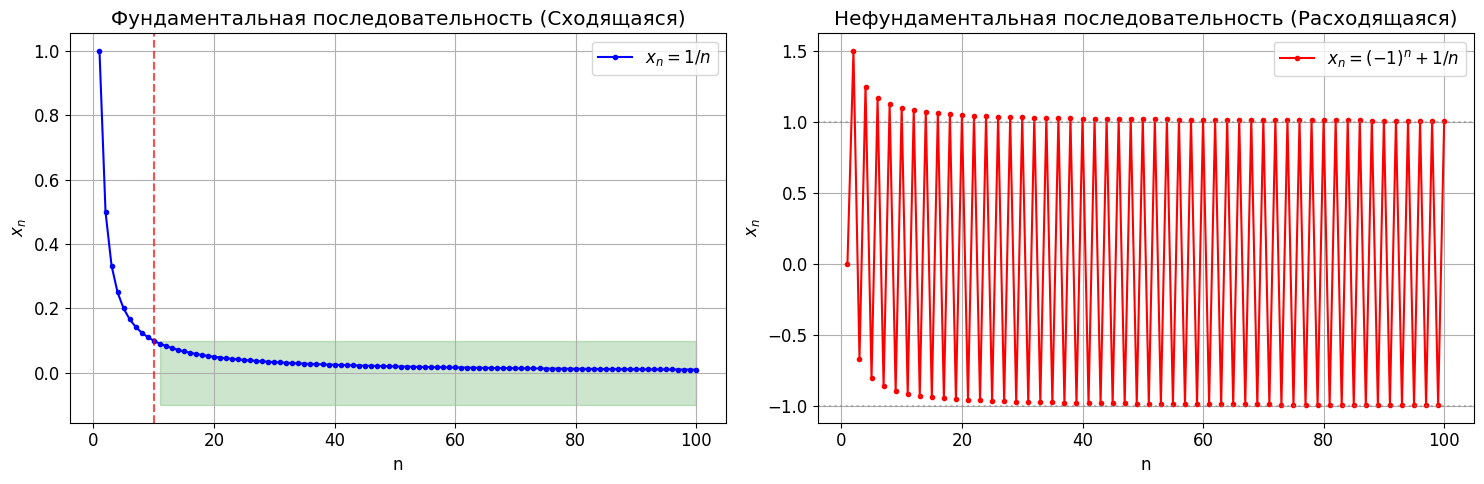

Поведение фундаментальной последовательности:
Для n, m > 10: |x_n - x_m| < 0.1
|x_11 - x_15| = 0.0208 < 0.1
|x_12 - x_16| = 0.0181 < 0.1
|x_13 - x_17| = 0.0159 < 0.1

Поведение нефундаментальной последовательности:
Члены колеблются и не остаются близкими:
|x_20 - x_21| = 1.9978
|x_21 - x_22| = 2.0020
|x_22 - x_23| = 1.9982


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Создаем последовательности
n = np.arange(1, 101)

# Фундаментальная последовательность (сходящаяся)
x_n_cauchy = 1 / n  # Сходится к 0

# Нефундаментальная последовательность (расходящаяся)
x_n_non_cauchy = (-1)**n + (1 / n)  # Колеблется между -1 и 1

# Создаем график
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# График фундаментальной последовательности
ax1.plot(n, x_n_cauchy, 'bo-', markersize=3, label=r'$x_n = 1/n$')
ax1.set_title('Фундаментальная последовательность (Сходящаяся)')
ax1.set_xlabel('n')
ax1.set_ylabel('$x_n$')
ax1.grid(True)
ax1.legend()

# Выделяем эпсилон-окрестность
epsilon = 0.1
N = int(1/epsilon)  # Для этой последовательности можно взять N = 1/epsilon
ax1.axvline(x=N, color='red', linestyle='--', alpha=0.7, label=f'N = {N}')
ax1.fill_between(n[N:], -epsilon, epsilon, alpha=0.2, color='green', 
                 label=f'$\\varepsilon = {epsilon}$')

# График нефундаментальной последовательности
ax2.plot(n, x_n_non_cauchy, 'ro-', markersize=3, label=r'$x_n = (-1)^n + 1/n$')
ax2.set_title('Нефундаментальная последовательность (Расходящаяся)')
ax2.set_xlabel('n')
ax2.set_ylabel('$x_n$')
ax2.grid(True)
ax2.legend()

# Показываем, что члены не сближаются
ax2.axhline(y=1, color='gray', linestyle=':', alpha=0.5)
ax2.axhline(y=-1, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

# Выводим значения для демонстрации свойства Коши
print("Поведение фундаментальной последовательности:")
print(f"Для n, m > {N}: |x_n - x_m| < {epsilon}")
for i in range(3):
    m, n_val = N + 1 + i, N + 5 + i
    diff = abs(x_n_cauchy[m] - x_n_cauchy[n_val])
    print(f"|x_{m} - x_{n_val}| = {diff:.4f} < {epsilon}")

print("\nПоведение нефундаментальной последовательности:")
print("Члены колеблются и не остаются близкими:")
for i in range(3):
    m, n_val = 20 + i, 21 + i
    diff = abs(x_n_non_cauchy[m] - x_n_non_cauchy[n_val])
    print(f"|x_{m} - x_{n_val}| = {diff:.4f}")